In [1]:
from google.colab import files

uploaded = files.upload()

Saving Metro_Interstate_Traffic_Volume.csv.gz to Metro_Interstate_Traffic_Volume.csv.gz


# Import Libraries

In [4]:
!pip install -q catboost lightgbm xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb
import lightgbm as lgb

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Load the Dataset

In [6]:
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv.gz")

# Understand the Dataset

In [7]:
# To check the number of rows and columns
print(df.shape)

(48204, 9)


In [8]:
# To display the first five rows
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [9]:
# To display the last five rows
df.tail()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450
48203,NaN,282.12,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 23:00:00,954


In [10]:
# To get the dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [11]:
# To check the data types
df.dtypes

,0
holiday,object
temp,float64
rain_1h,float64
snow_1h,float64
clouds_all,int64
weather_main,object
weather_description,object
date_time,object
traffic_volume,int64


In [12]:
# To check the numerical statistics
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [13]:
# To check the missing values
print(df.isnull().sum())

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64


In [14]:
# To check the number of duplicated rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 17


In [15]:
# To display the duplicated rows
df[df.duplicated()]

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
18697,NaN,286.290,0.0,0.0,1,Clear,sky is clear,2015-09-30 19:00:00,3679
23851,NaN,289.060,0.0,0.0,90,Clouds,overcast clouds,2016-06-01 10:00:00,4831
26784,NaN,289.775,0.0,0.0,56,Clouds,broken clouds,2016-09-21 15:00:00,5365
26980,NaN,287.860,0.0,0.0,0,Clear,Sky is Clear,2016-09-29 19:00:00,3435
27171,NaN,279.287,0.0,0.0,56,Clouds,broken clouds,2016-10-07 18:00:00,4642
28879,NaN,267.890,0.0,0.0,90,Snow,light snow,2016-12-06 18:00:00,4520
29268,NaN,254.220,0.0,0.0,1,Clear,sky is clear,2016-12-19 00:00:00,420
34711,NaN,295.010,0.0,0.0,40,Clouds,scattered clouds,2017-06-21 11:00:00,4808
34967,NaN,292.840,0.0,0.0,1,Clear,sky is clear,2017-06-30 10:00:00,4638
34969,NaN,294.520,0.0,0.0,1,Clear,sky is clear,2017-06-30 11:00:00,4725


In [16]:
# Remove exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Verify
print("Duplicate rows:", df.duplicated().sum())
print("New shape:", df.shape)

Duplicate rows: 0
New shape: (48187, 9)


# Handling Missing Values

In [17]:
# To fill the missing "holiday" column with "None"
df["holiday"] = df["holiday"].fillna("None")

In [18]:
df.isnull().sum()

,0
holiday,0
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0


In [19]:
# To check the value_counts of "holiday"
print(df["holiday"].value_counts())

holiday
None                         48126
Labor Day                        7
Christmas Day                    6
Thanksgiving Day                 6
Martin Luther King Jr Day        6
New Years Day                    6
Veterans Day                     5
Columbus Day                     5
Memorial Day                     5
Washingtons Birthday             5
State Fair                       5
Independence Day                 5
Name: count, dtype: int64


In [20]:
# To convert into date_time
df["date_time"] = pd.to_datetime(df["date_time"])

In [21]:
df.dtypes

,0
holiday,object
temp,float64
rain_1h,float64
snow_1h,float64
clouds_all,int64
weather_main,object
weather_description,object
date_time,datetime64[ns]
traffic_volume,int64


In [22]:
# To sort the dataset by date_time
df = df.sort_values("date_time").reset_index(drop=True)

In [23]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [24]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Shape: (48187, 9)

Missing values:
holiday                0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
traffic_volume         0
dtype: int64

Duplicate rows: 0

Data types:
holiday                        object
temp                          float64
rain_1h                       float64
snow_1h                       float64
clouds_all                      int64
weather_main                   object
weather_description            object
date_time              datetime64[ns]
traffic_volume                  int64
dtype: object


In [25]:
print("Holiday values:")
print(df["holiday"].value_counts())

print("\nWeather main values:")
print(df["weather_main"].value_counts())

print("\nWeather description values:")
print(df["weather_description"].value_counts())

Holiday values:
holiday
None                         48126
Labor Day                        7
Christmas Day                    6
Thanksgiving Day                 6
Martin Luther King Jr Day        6
New Years Day                    6
Veterans Day                     5
Columbus Day                     5
Memorial Day                     5
Washingtons Birthday             5
State Fair                       5
Independence Day                 5
Name: count, dtype: int64

Weather main values:
weather_main
Clouds          15158
Clear           13384
Mist             5949
Rain             5672
Snow             2875
Drizzle          1820
Haze             1360
Thunderstorm     1033
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64

Weather description values:
weather_description
sky is clear                           11659
mist                                    5949
overcast clouds                         5079
broken clouds                           466

In [26]:
print("\nNumber of unique values:")
print(df.nunique())


Number of unique values:
holiday                   12
temp                    5843
rain_1h                  372
snow_1h                   12
clouds_all                60
weather_main              11
weather_description       38
date_time              40575
traffic_volume          6704
dtype: int64


In [27]:
duplicate_timestamps = df[df["date_time"].duplicated(keep=False)].sort_values("date_time")

print("Rows with duplicate timestamps:", len(duplicate_timestamps))
print("Number of duplicated timestamp groups:",
      duplicate_timestamps["date_time"].nunique())

Rows with duplicate timestamps: 13042
Number of duplicated timestamp groups: 5430


In [28]:
duplicate_timestamps.head(20)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
178,None,281.25,0.0,0.0,99,Rain,light rain,2012-10-10 07:00:00,6793
179,None,281.25,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 07:00:00,6793
180,None,280.10,0.0,0.0,99,Rain,light rain,2012-10-10 08:00:00,6283
181,None,280.10,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 08:00:00,6283
182,None,279.61,0.0,0.0,99,Rain,light rain,2012-10-10 09:00:00,5680
183,None,279.61,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 09:00:00,5680
269,None,282.43,0.0,0.0,57,Drizzle,light intensity drizzle,2012-10-14 09:00:00,2685
270,None,282.43,0.0,0.0,57,Mist,mist,2012-10-14 09:00:00,2685
271,None,282.43,0.0,0.0,57,Haze,haze,2012-10-14 09:00:00,2685
272,None,282.33,0.0,0.0,57,Drizzle,light intensity drizzle,2012-10-14 10:00:00,3370


In [29]:
# Check whether duplicated timestamps have different traffic values
timestamp_traffic = (
    df.groupby("date_time")["traffic_volume"]
      .nunique()
)

print("Timestamps with multiple traffic values:",
      (timestamp_traffic > 1).sum())

print("Maximum number of different traffic values for one timestamp:",
      timestamp_traffic.max())

Timestamps with multiple traffic values: 0
Maximum number of different traffic values for one timestamp: 1


In [30]:
# Check exact duplicate rows
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 0


In [31]:
# Show timestamps where traffic_volume differs
different_traffic = timestamp_traffic[timestamp_traffic > 1]

print(different_traffic.head(20))

Series([], Name: traffic_volume, dtype: int64)


In [32]:
duplicate_rows = df[df["date_time"].duplicated(keep=False)]

summary = duplicate_rows.groupby("date_time").agg({
    "holiday": "nunique",
    "temp": "nunique",
    "rain_1h": "nunique",
    "snow_1h": "nunique",
    "clouds_all": "nunique",
    "weather_main": "nunique",
    "weather_description": "nunique",
    "traffic_volume": "nunique"
})

print(summary.head(20))

                     holiday  temp  rain_1h  snow_1h  clouds_all  \
date_time                                                          
2012-10-10 07:00:00        1     1        1        1           1   
2012-10-10 08:00:00        1     1        1        1           1   
2012-10-10 09:00:00        1     1        1        1           1   
2012-10-14 09:00:00        1     1        1        1           1   
2012-10-14 10:00:00        1     1        1        1           1   
2012-10-14 11:00:00        1     1        1        1           1   
2012-10-14 12:00:00        1     1        1        1           1   
2012-10-14 13:00:00        1     1        1        1           1   
2012-10-14 14:00:00        1     1        1        1           1   
2012-10-14 15:00:00        1     1        1        1           1   
2012-10-14 17:00:00        1     1        1        1           1   
2012-10-14 23:00:00        1     1        1        1           1   
2012-10-15 00:00:00        1     1        1     

In [33]:
df_unique = df.drop_duplicates(subset="date_time", keep="first")

print("Original rows:", len(df))
print("Rows after removing repeated timestamps:", len(df_unique))
print("Rows removed:", len(df) - len(df_unique))

Original rows: 48187
Rows after removing repeated timestamps: 40575
Rows removed: 7612


In [34]:
df_clean = df.drop_duplicates(
    subset="date_time",
    keep="first"
).copy()

print("Cleaned dataset shape:", df_clean.shape)
print("Duplicate timestamps:", df_clean["date_time"].duplicated().sum())

Cleaned dataset shape: (40575, 9)
Duplicate timestamps: 0


# Feature Engineering

In [35]:
# Time Features

# Hour of the day (0–23)
df_clean["hour"] = df_clean["date_time"].dt.hour

# Day of the month
df_clean["day"] = df_clean["date_time"].dt.day

# Monday=0 → Sunday=6
df_clean["day_of_week"] = df_clean["date_time"].dt.dayofweek

# Month (1–12)
df_clean["month"] = df_clean["date_time"].dt.month

# Year
df_clean["year"] = df_clean["date_time"].dt.year

In [36]:
# Weekend indicator

# 1 = Saturday/Sunday, 0 = weekday
df_clean["is_weekend"] = (df_clean["day_of_week"] >= 5).astype(int)

In [37]:
# To display the new features
df_clean[[
    "date_time",
    "hour",
    "day",
    "day_of_week",
    "month",
    "year",
    "is_weekend"
]].head()

,date_time,hour,day,day_of_week,month,year,is_weekend
0,2012-10-02 09:00:00,9,2,1,10,2012,0
1,2012-10-02 10:00:00,10,2,1,10,2012,0
2,2012-10-02 11:00:00,11,2,1,10,2012,0
3,2012-10-02 12:00:00,12,2,1,10,2012,0
4,2012-10-02 13:00:00,13,2,1,10,2012,0


In [38]:
print(df_clean.shape)
df_clean.head()

(40575, 15)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day,day_of_week,month,year,is_weekend
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,2,1,10,2012,0
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,2,1,10,2012,0
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,2,1,10,2012,0
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,2,1,10,2012,0
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,2,1,10,2012,0


In [39]:
print(df_clean.columns.tolist())

['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume', 'hour', 'day', 'day_of_week', 'month', 'year', 'is_weekend']


In [40]:
print(df_clean[[
    "date_time",
    "hour",
    "day",
    "day_of_week",
    "month",
    "year",
    "is_weekend"
]].head(10))

            date_time  hour  day  day_of_week  month  year  is_weekend
0 2012-10-02 09:00:00     9    2            1     10  2012           0
1 2012-10-02 10:00:00    10    2            1     10  2012           0
2 2012-10-02 11:00:00    11    2            1     10  2012           0
3 2012-10-02 12:00:00    12    2            1     10  2012           0
4 2012-10-02 13:00:00    13    2            1     10  2012           0
5 2012-10-02 14:00:00    14    2            1     10  2012           0
6 2012-10-02 15:00:00    15    2            1     10  2012           0
7 2012-10-02 16:00:00    16    2            1     10  2012           0
8 2012-10-02 17:00:00    17    2            1     10  2012           0
9 2012-10-02 18:00:00    18    2            1     10  2012           0


In [41]:
print(df_clean[[
    "hour",
    "day",
    "day_of_week",
    "month",
    "year",
    "is_weekend"
]].describe())

               hour           day   day_of_week         month          year  \
count  40575.000000  40575.000000  40575.000000  40575.000000  40575.000000   
mean      11.514750     15.672754      3.006778      6.489045   2015.479729   
std        6.949889      8.763954      1.998947      3.373618      1.888817   
min        0.000000      1.000000      0.000000      1.000000   2012.000000   
25%        5.000000      8.000000      1.000000      4.000000   2014.000000   
50%       12.000000     16.000000      3.000000      7.000000   2016.000000   
75%       18.000000     23.000000      5.000000      9.000000   2017.000000   
max       23.000000     31.000000      6.000000     12.000000   2018.000000   

         is_weekend  
count  40575.000000  
mean       0.285792  
std        0.451796  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        1.000000  
max        1.000000  


# Exploratory Data Analysis - EDA

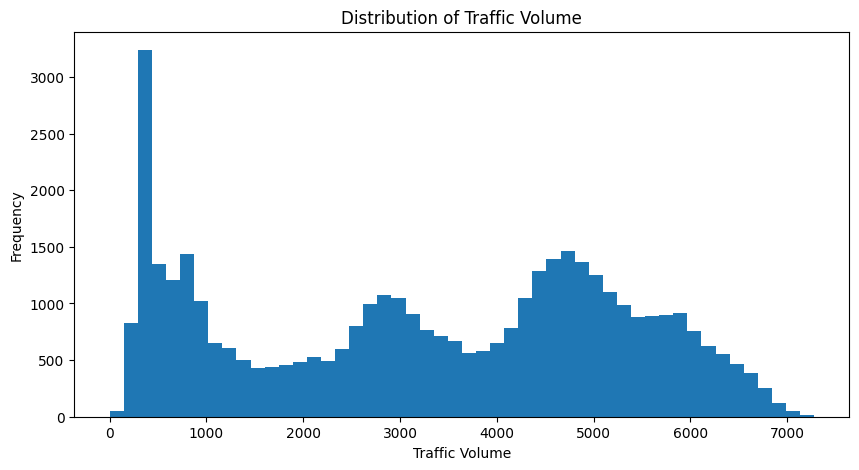

In [42]:
# Distribution of Traffic Volume

plt.figure(figsize=(10, 5))

plt.hist(df_clean["traffic_volume"], bins=50)

plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.title("Distribution of Traffic Volume")

plt.savefig("Distribution of Traffic Volume")
plt.show()

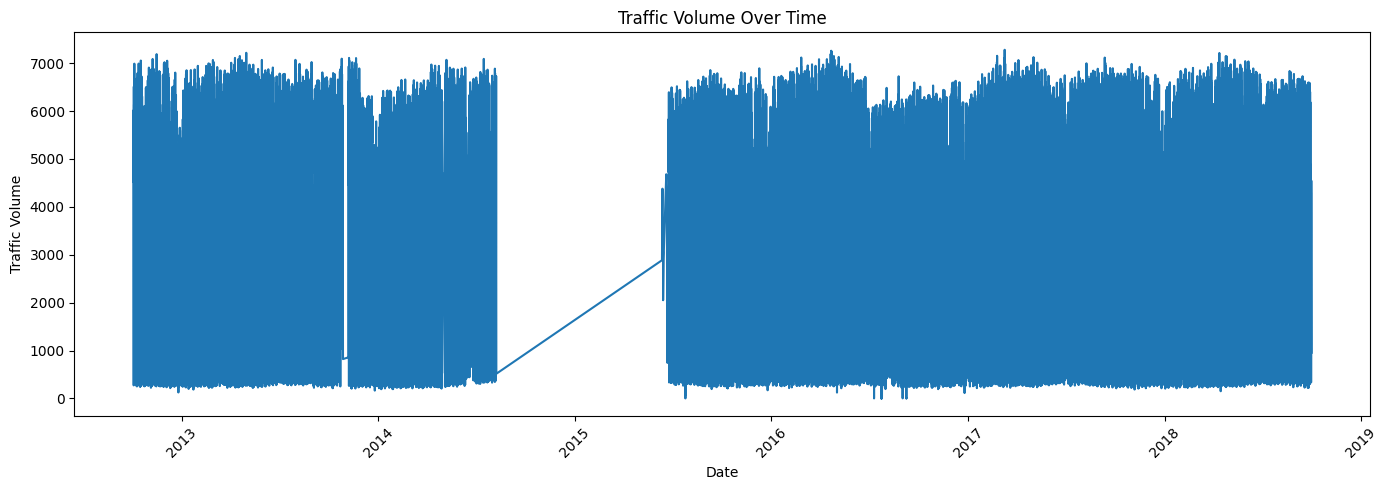

In [43]:
# Traffic Volume Over Time

plt.figure(figsize=(14, 5))

plt.plot(
    df_clean["date_time"],
    df_clean["traffic_volume"]
)

plt.xlabel("Date")
plt.ylabel("Traffic Volume")
plt.title("Traffic Volume Over Time")

plt.xticks(rotation=45)
plt.savefig("Traffic Volume Over Time")
plt.tight_layout()
plt.show()

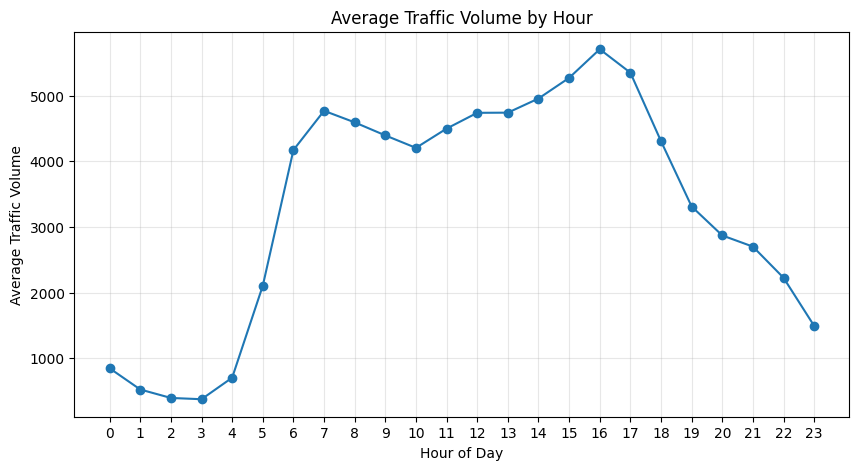

In [44]:
# Average traffic volume by hour

hourly_traffic = df_clean.groupby("hour")["traffic_volume"].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_traffic.index,
    hourly_traffic.values,
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")
plt.title("Average Traffic Volume by Hour")

plt.xticks(range(24))

plt.savefig("Average Traffic Volume by Hour")
plt.grid(True, alpha=0.3)

plt.show()

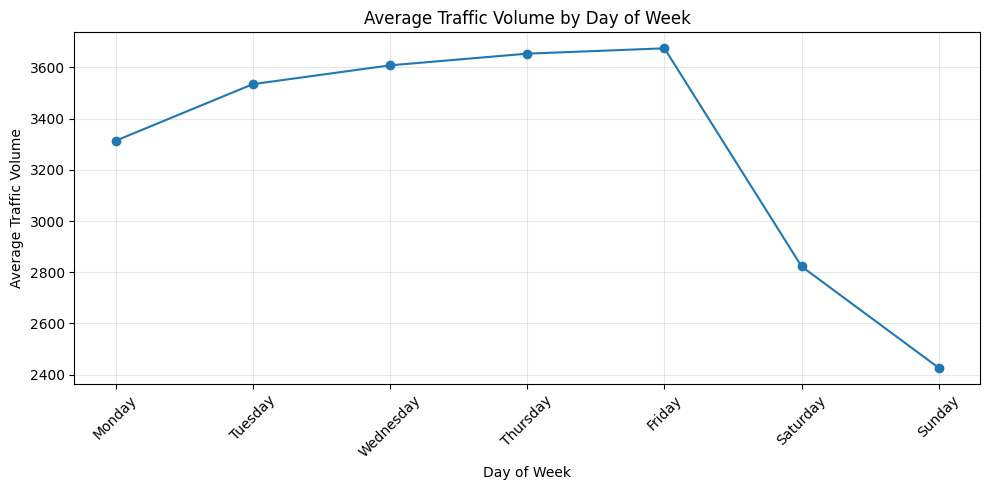

In [45]:
# Average Traffic Volume by Day of Week

day_traffic = df_clean.groupby("day_of_week")["traffic_volume"].mean()

day_names = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

plt.figure(figsize=(10, 5))

plt.plot(
    day_names,
    day_traffic.values,
    marker="o"
)

plt.xlabel("Day of Week")
plt.ylabel("Average Traffic Volume")
plt.title("Average Traffic Volume by Day of Week")

plt.savefig("Average Traffic Volume by Day of Week")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

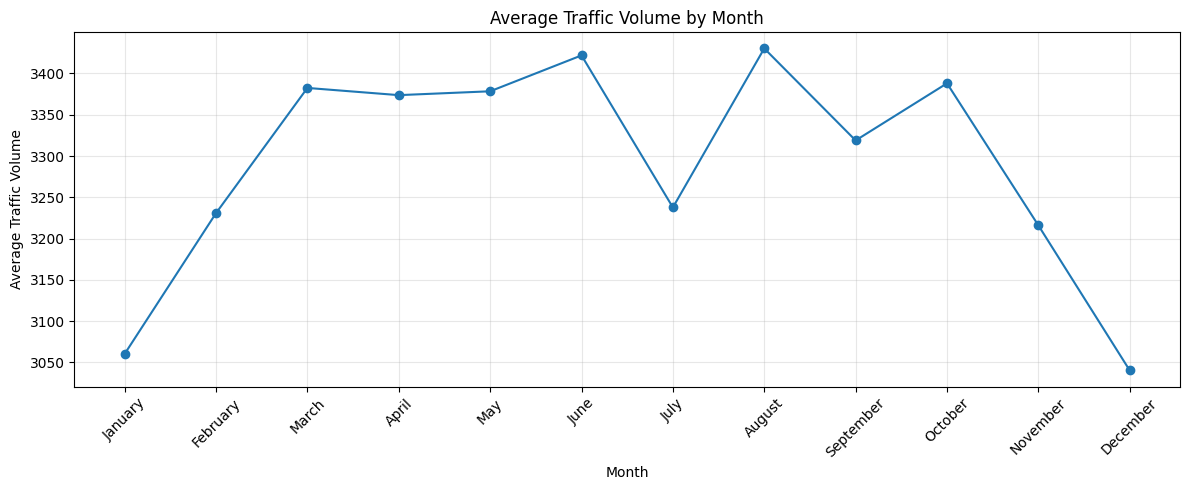

In [46]:
# Average Traffic Volume by Month

monthly_traffic = df_clean.groupby("month")["traffic_volume"].mean()

month_names = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

plt.figure(figsize=(12, 5))

plt.plot(
    month_names,
    monthly_traffic.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Traffic Volume")
plt.title("Average Traffic Volume by Month")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.savefig("Average Traffic Volume by Month")
plt.tight_layout()
plt.show()

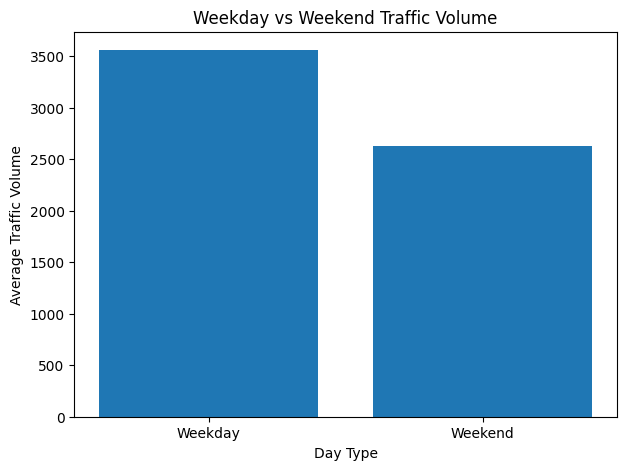

In [47]:
# Weekday vs Weekend Traffic

weekday_weekend = df_clean.groupby("is_weekend")["traffic_volume"].mean()

labels = ["Weekday", "Weekend"]

plt.figure(figsize=(7, 5))

plt.bar(
    labels,
    weekday_weekend.values
)

plt.xlabel("Day Type")
plt.ylabel("Average Traffic Volume")
plt.title("Weekday vs Weekend Traffic Volume")

plt.savefig("Weekday vs Weekend Traffic Volume")
plt.show()

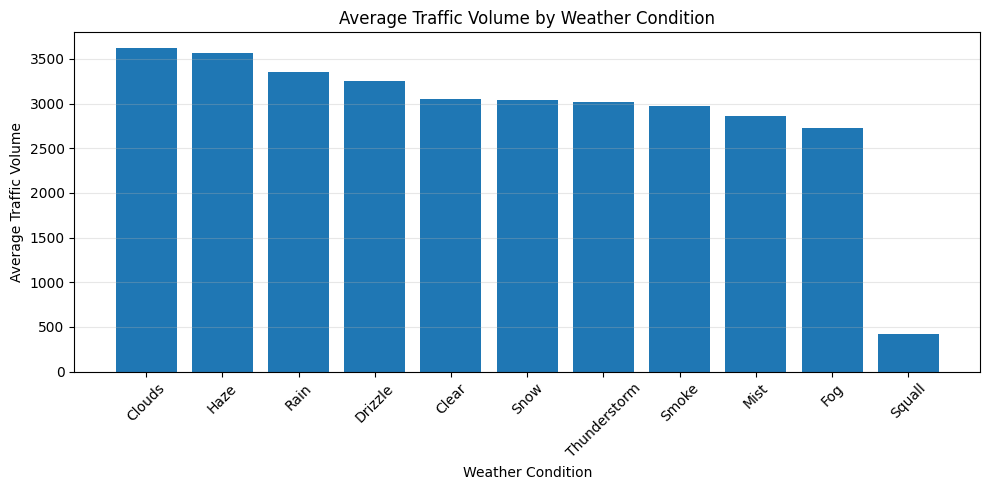

In [48]:
# Weather Condition vs Traffic Volume

weather_traffic = (
    df_clean.groupby("weather_main")["traffic_volume"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    weather_traffic.index,
    weather_traffic.values
)

plt.xlabel("Weather Condition")
plt.ylabel("Average Traffic Volume")
plt.title("Average Traffic Volume by Weather Condition")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.savefig("Average Traffic Volume by Weather Condition")
plt.tight_layout()
plt.show()

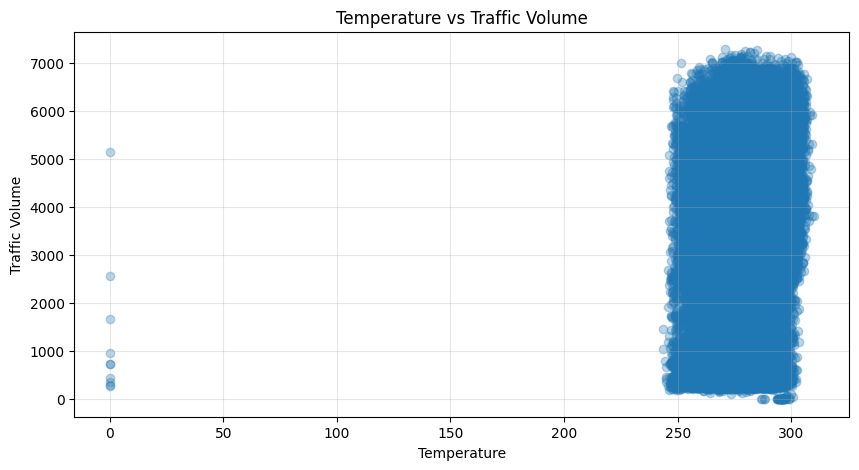

In [49]:
# Temperature vs Traffic Volume

plt.figure(figsize=(10, 5))

plt.scatter(
    df_clean["temp"],
    df_clean["traffic_volume"],
    alpha=0.3
)

plt.xlabel("Temperature")
plt.ylabel("Traffic Volume")
plt.title("Temperature vs Traffic Volume")

plt.grid(True, alpha=0.3)

plt.savefig("Temperature vs Traffic Volume")
plt.show()

In [50]:
df_clean.dtypes

,0
holiday,object
temp,float64
rain_1h,float64
snow_1h,float64
clouds_all,int64
weather_main,object
weather_description,object
date_time,datetime64[ns]
traffic_volume,int64
hour,int32


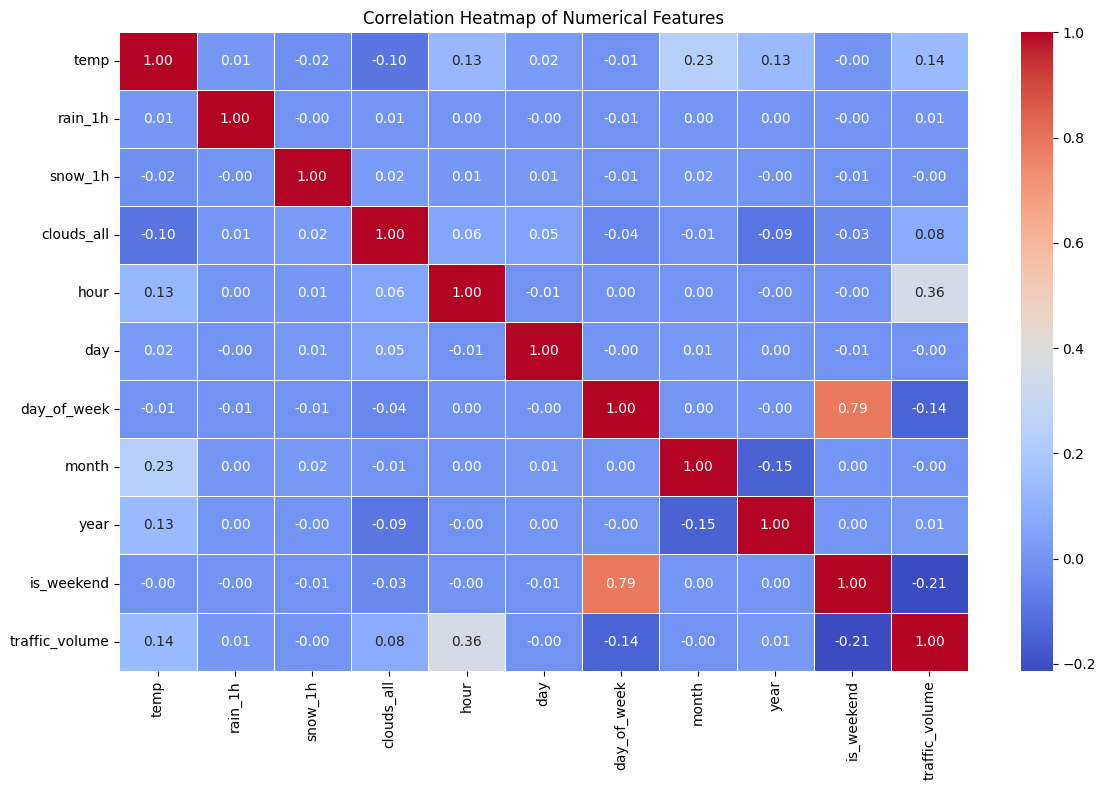

In [51]:
# Select numerical features for correlation analysis

numeric_cols = [
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'hour',
    'day',
    'day_of_week',
    'month',
    'year',
    'is_weekend',
    'traffic_volume'
]

correlation_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.savefig("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [52]:
print("Holiday categories:")
print(df_clean["holiday"].unique())

print("\nWeather main categories:")
print(df_clean["weather_main"].unique())

print("\nWeather description categories:")
print(df_clean["weather_description"].unique())

Holiday categories:
['None' 'Columbus Day' 'Veterans Day' 'Thanksgiving Day' 'Christmas Day'
 'New Years Day' 'Washingtons Birthday' 'Memorial Day' 'Independence Day'
 'State Fair' 'Labor Day' 'Martin Luther King Jr Day']

Weather main categories:
['Clouds' 'Clear' 'Rain' 'Drizzle' 'Mist' 'Fog' 'Thunderstorm' 'Haze'
 'Snow' 'Squall' 'Smoke']

Weather description categories:
['scattered clouds' 'broken clouds' 'overcast clouds' 'sky is clear'
 'few clouds' 'light rain' 'light intensity drizzle' 'mist' 'fog'
 'proximity shower rain' 'moderate rain' 'drizzle' 'heavy intensity rain'
 'proximity thunderstorm' 'haze' 'thunderstorm with light rain'
 'proximity thunderstorm with rain' 'heavy snow' 'snow'
 'light rain and snow' 'light intensity shower rain' 'SQUALLS'
 'thunderstorm with heavy rain' 'thunderstorm with rain'
 'heavy intensity drizzle' 'Sky is Clear' 'very heavy rain'
 'thunderstorm with light drizzle' 'thunderstorm' 'light snow' 'smoke'
 'proximity thunderstorm with drizzle' 'fre

In [53]:
print(df_clean[[
    "holiday",
    "weather_main",
    "weather_description"
]].nunique())

holiday                12
weather_main           11
weather_description    36
dtype: int64


In [54]:
df_clean = df_clean.drop(columns=["weather_description"]).copy()

print("ML dataset shape:", df_clean.shape)
print(df_clean.columns.tolist())

ML dataset shape: (40575, 14)
['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'date_time', 'traffic_volume', 'hour', 'day', 'day_of_week', 'month', 'year', 'is_weekend']


# Define Features and Target

In [55]:
feature_cols = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "holiday",
    "weather_main",
    "hour",
    "day",
    "day_of_week",
    "month",
    "year",
    "is_weekend"
]

X = df_clean[feature_cols]
y = df_clean["traffic_volume"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (40575, 12)
y shape: (40575,)


In [56]:
df_clean.to_csv("smart_traffic_ml_cleaned.csv", index=False)

print("Cleaned ML dataset saved successfully.")

Cleaned ML dataset saved successfully.


In [57]:
categorical_features = [
    "holiday",
    "weather_main"
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoded = encoder.fit_transform(X[categorical_features])

print("Encoded shape:", encoded.shape)

Encoded shape: (40575, 23)


In [58]:
numerical_features = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "hour",
    "day",
    "day_of_week",
    "month",
    "year",
    "is_weekend"
]

X_numeric = X[numerical_features].reset_index(drop=True)

In [59]:
encoded_columns = encoder.get_feature_names_out(categorical_features)

X_encoded = pd.DataFrame(
    encoded,
    columns=encoded_columns
)

print("Encoded categorical features:")
print(X_encoded.head())

Encoded categorical features:
   holiday_Christmas Day  holiday_Columbus Day  holiday_Independence Day  \
0                    0.0                   0.0                       0.0   
1                    0.0                   0.0                       0.0   
2                    0.0                   0.0                       0.0   
3                    0.0                   0.0                       0.0   
4                    0.0                   0.0                       0.0   

   holiday_Labor Day  holiday_Martin Luther King Jr Day  holiday_Memorial Day  \
0                0.0                                0.0                   0.0   
1                0.0                                0.0                   0.0   
2                0.0                                0.0                   0.0   
3                0.0                                0.0                   0.0   
4                0.0                                0.0                   0.0   

   holiday_New Years Day  

In [60]:
X = pd.concat(
    [X_numeric, X_encoded],
    axis=1
)

print("Final X shape:", X.shape)
print("Final feature count:", len(X.columns))

Final X shape: (40575, 33)
Final feature count: 33


# Chronological train-test split

In [61]:
# Chronological train-test split

split_index = int(len(df_clean) * 0.80)

train_data = df_clean.iloc[:split_index].copy()
test_data = df_clean.iloc[split_index:].copy()

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

print("\nTraining period:")
print(train_data["date_time"].min(), "→", train_data["date_time"].max())

print("\nTesting period:")
print(test_data["date_time"].min(), "→", test_data["date_time"].max())

Training data shape: (32460, 14)
Testing data shape: (8115, 14)

Training period:
2012-10-02 09:00:00 → 2017-10-26 17:00:00

Testing period:
2017-10-26 18:00:00 → 2018-09-30 23:00:00


In [62]:
feature_columns = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "holiday",
    "weather_main",
    "hour",
    "day",
    "day_of_week",
    "month",
    "year",
    "is_weekend"
]

X_train = train_data[feature_columns]
y_train = train_data["traffic_volume"]

X_test = test_data[feature_columns]
y_test = test_data["traffic_volume"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (32460, 12)
y_train: (32460,)
X_test: (8115, 12)
y_test: (8115,)


In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Numerical and categorical columns
numerical_features = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "hour",
    "day",
    "day_of_week",
    "month",
    "year",
    "is_weekend"
]

categorical_features = [
    "holiday",
    "weather_main"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [64]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (32460, 33)
Processed testing shape: (8115, 33)


# Linear Regression Model

In [65]:
# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train_processed, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [66]:
# Predictions on test data
y_pred_lr = lr_model.predict(X_test_processed)

print("Number of predictions:", len(y_pred_lr))
print("First 10 predictions:")
print(y_pred_lr[:10])

Number of predictions: 8115
First 10 predictions:
[4406.91668926 4151.25392809 4239.16288919 4652.25736739 4402.2776151
 4491.8580494  2399.21970182 2372.77565389 2583.72928466 2678.49128588]


In [67]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("--------------------------")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
--------------------------
MAE : 1551.453976978467
MSE : 3122024.9131534775
RMSE: 1766.9252709589837
R²  : 0.19559357066523453


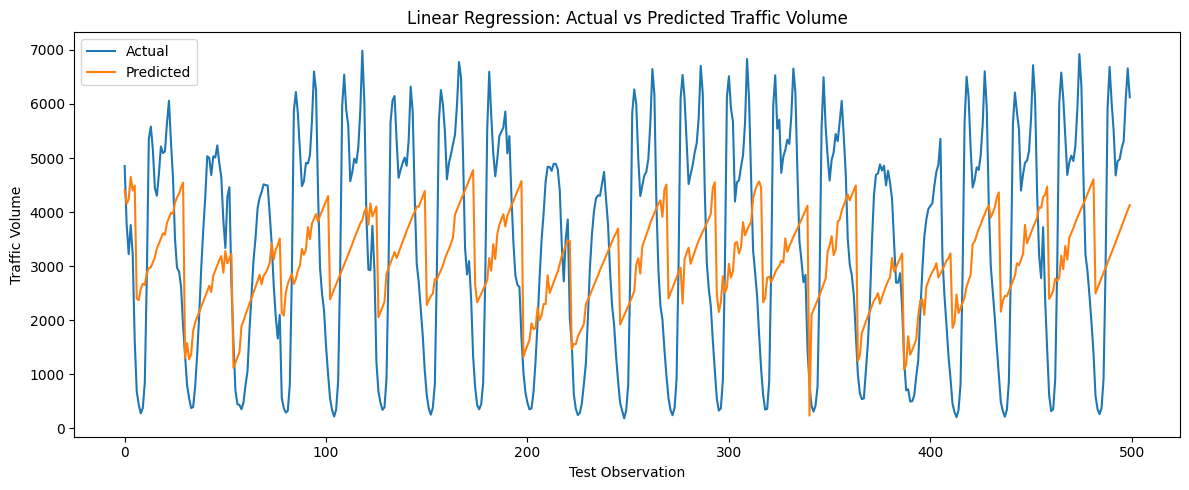

In [68]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:500],
    label="Actual"
)

plt.plot(
    y_pred_lr[:500],
    label="Predicted"
)

plt.xlabel("Test Observation")
plt.ylabel("Traffic Volume")
plt.title("Linear Regression: Actual vs Predicted Traffic Volume")
plt.legend()

plt.tight_layout()
plt.show()

In [69]:
results_lr = []

results_lr.append({
    "Model": "Linear Regression",
    "MAE": mae_lr,
    "MSE": mse_lr,
    "RMSE": rmse_lr,
    "R2": r2_lr
})

results_df_lr = pd.DataFrame(results_lr)

print(results_df_lr)

               Model          MAE           MSE         RMSE        R2
0  Linear Regression  1551.453977  3.122025e+06  1766.925271  0.195594


# Random Forest Model

In [70]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [71]:
y_pred_rf = rf_model.predict(X_test_processed)

print("Number of predictions:", len(y_pred_rf))

Number of predictions: 8115


In [72]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("--------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
--------------------
MAE : 254.52940727048676
MSE : 188041.16806331484
RMSE: 433.63713870391086
R²  : 0.9515501865688304


In [73]:
results_rf = []

results_rf.append({
    "Model": "Random Forest",
    "MAE": mae_rf,
    "MSE": mse_rf,
    "RMSE": rmse_rf,
    "R2": r2_rf
})

results_df_rf = pd.DataFrame(results_rf)

print(results_df_rf)

           Model         MAE            MSE        RMSE       R2
0  Random Forest  254.529407  188041.168063  433.637139  0.95155


In [74]:
results_df = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": mae_lr,
        "MSE": mse_lr,
        "RMSE": rmse_lr,
        "R2": r2_lr
    },
    {
        "Model": "Random Forest",
        "MAE": mae_rf,
        "MSE": mse_rf,
        "RMSE": rmse_rf,
        "R2": r2_rf
    }
])

print(results_df)

               Model          MAE           MSE         RMSE        R2
0  Linear Regression  1551.453977  3.122025e+06  1766.925271  0.195594
1      Random Forest   254.529407  1.880412e+05   433.637139  0.951550


In [75]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

                     Feature  Importance
4                  num__hour    0.833412
6           num__day_of_week    0.058424
9            num__is_weekend    0.047313
0                  num__temp    0.017934
5                   num__day    0.016501
7                 num__month    0.010835
8                  num__year    0.005625
3            num__clouds_all    0.003631
1               num__rain_1h    0.001504
23  cat__weather_main_Clouds    0.001093
27    cat__weather_main_Mist    0.000821
30    cat__weather_main_Snow    0.000767
22   cat__weather_main_Clear    0.000632
28    cat__weather_main_Rain    0.000543
26    cat__weather_main_Haze    0.000425


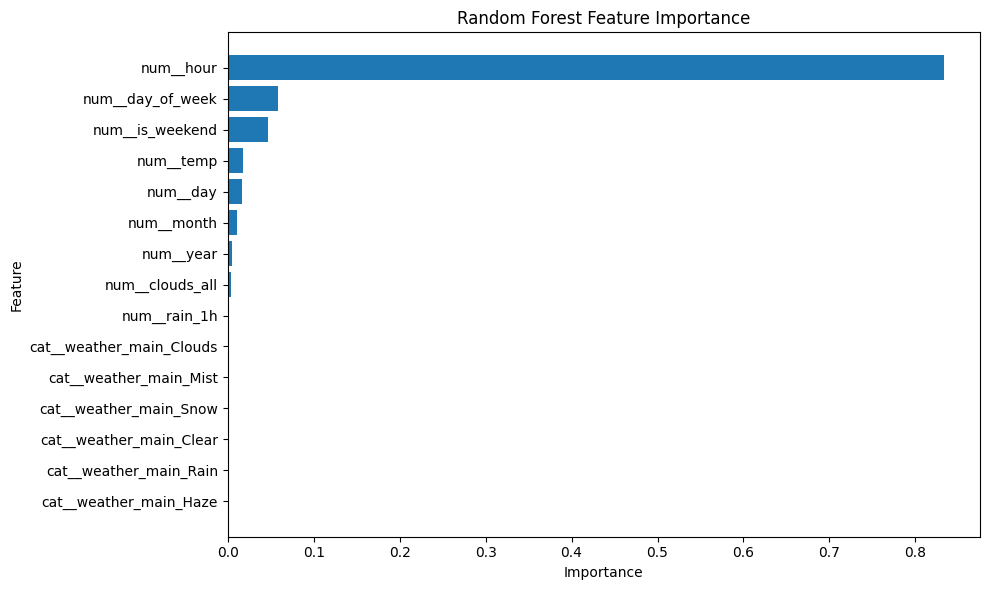

In [76]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"].head(15)[::-1],
    feature_importance["Importance"].head(15)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

XGBoost Model

In [77]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train
)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [78]:
y_pred_xgb = xgb_model.predict(X_test_processed)

print("Number of predictions:", len(y_pred_xgb))

Number of predictions: 8115


In [79]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("----------------")
print("MAE :", mae_xgb)
print("MSE :", mse_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost Results
----------------
MAE : 246.69630432128906
MSE : 166466.5625
RMSE: 408.00314030654226
R²  : 0.9571089744567871


In [80]:
results_df = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": mae_lr,
        "MSE": mse_lr,
        "RMSE": rmse_lr,
        "R2": r2_lr
    },
    {
        "Model": "Random Forest",
        "MAE": mae_rf,
        "MSE": mse_rf,
        "RMSE": rmse_rf,
        "R2": r2_rf
    },
    {
    "Model": "XGBoost",
    "MAE": mae_xgb,
    "MSE": mse_xgb,
    "RMSE": rmse_xgb,
    "R2": r2_xgb
}
])

print(results_df)

               Model          MAE           MSE         RMSE        R2
0  Linear Regression  1551.453977  3.122025e+06  1766.925271  0.195594
1      Random Forest   254.529407  1.880412e+05   433.637139  0.951550
2            XGBoost   246.696304  1.664666e+05   408.003140  0.957109


# LightGBM Model

In [81]:
lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(
    X_train_processed,
    y_train
)

print("LightGBM model trained successfully!")

LightGBM model trained successfully!


In [82]:
y_pred_lgb = lgb_model.predict(X_test_processed)

print("Number of predictions:", len(y_pred_lgb))

Number of predictions: 8115


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [83]:
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
mse_lgb = mean_squared_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mse_lgb)
r2_lgb = r2_score(y_test, y_pred_lgb)

print("LightGBM Results")
print("----------------")
print("MAE :", mae_lgb)
print("MSE :", mse_lgb)
print("RMSE:", rmse_lgb)
print("R²  :", r2_lgb)

LightGBM Results
----------------
MAE : 249.80601202909074
MSE : 170702.04405726693
RMSE: 413.16103889072957
R²  : 0.9560177046756636


In [84]:
results_df = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": mae_lr,
        "MSE": mse_lr,
        "RMSE": rmse_lr,
        "R2": r2_lr
    },
    {
        "Model": "Random Forest",
        "MAE": mae_rf,
        "MSE": mse_rf,
        "RMSE": rmse_rf,
        "R2": r2_rf
    },
    {
    "Model": "XGBoost",
    "MAE": mae_xgb,
    "MSE": mse_xgb,
    "RMSE": rmse_xgb,
    "R2": r2_xgb
    },
    {
    "Model": "LightGBM",
    "MAE": mae_lgb,
    "MSE": mse_lgb,
    "RMSE": rmse_lgb,
    "R2": r2_lgb
}
])

print(results_df)

               Model          MAE           MSE         RMSE        R2
0  Linear Regression  1551.453977  3.122025e+06  1766.925271  0.195594
1      Random Forest   254.529407  1.880412e+05   433.637139  0.951550
2            XGBoost   246.696304  1.664666e+05   408.003140  0.957109
3           LightGBM   249.806012  1.707020e+05   413.161039  0.956018


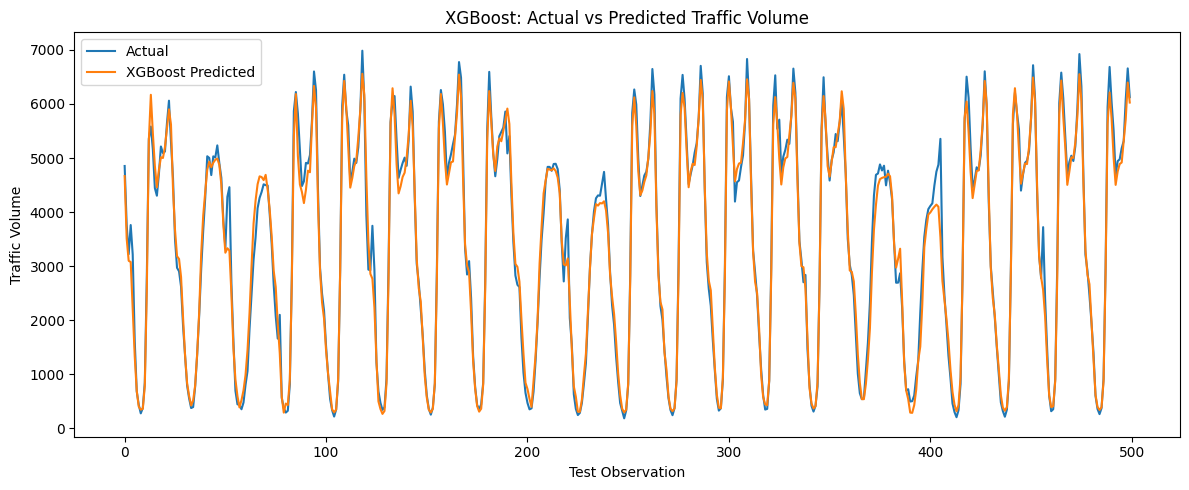

In [85]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:500],
    label="Actual"
)

plt.plot(
    y_pred_xgb[:500],
    label="XGBoost Predicted"
)

plt.xlabel("Test Observation")
plt.ylabel("Traffic Volume")
plt.title("XGBoost: Actual vs Predicted Traffic Volume")
plt.legend()

plt.tight_layout()
plt.show()

# CatBoost Model

In [86]:
from catboost import CatBoostRegressor

print("CatBoost imported successfully!")

CatBoost imported successfully!


In [87]:
cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

cat_model.fit(
    X_train_processed,
    y_train
)

print("CatBoost model trained successfully!")

CatBoost model trained successfully!


In [88]:
y_pred_cat = cat_model.predict(X_test_processed)

print("Number of predictions:", len(y_pred_cat))

Number of predictions: 8115


In [89]:
mae_cat = mean_absolute_error(y_test, y_pred_cat)
mse_cat = mean_squared_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
r2_cat = r2_score(y_test, y_pred_cat)

print("CatBoost Results")
print("----------------")
print("MAE :", mae_cat)
print("MSE :", mse_cat)
print("RMSE:", rmse_cat)
print("R²  :", r2_cat)

CatBoost Results
----------------
MAE : 247.7037844439172
MSE : 176365.60947819916
RMSE: 419.9590569069789
R²  : 0.9545584567310487


# Models Comparison

In [90]:
results_df = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": mae_lr,
        "MSE": mse_lr,
        "RMSE": rmse_lr,
        "R2": r2_lr
    },
    {
        "Model": "Random Forest",
        "MAE": mae_rf,
        "MSE": mse_rf,
        "RMSE": rmse_rf,
        "R2": r2_rf
    },
    {
    "Model": "XGBoost",
    "MAE": mae_xgb,
    "MSE": mse_xgb,
    "RMSE": rmse_xgb,
    "R2": r2_xgb
    },
    {
    "Model": "LightGBM",
    "MAE": mae_lgb,
    "MSE": mse_lgb,
    "RMSE": rmse_lgb,
    "R2": r2_lgb
    },
    {
    "Model": "CatBoost",
    "MAE": mae_cat,
    "MSE": mse_cat,
    "RMSE": rmse_cat,
    "R2": r2_cat
}
])

print(results_df)

               Model          MAE           MSE         RMSE        R2
0  Linear Regression  1551.453977  3.122025e+06  1766.925271  0.195594
1      Random Forest   254.529407  1.880412e+05   433.637139  0.951550
2            XGBoost   246.696304  1.664666e+05   408.003140  0.957109
3           LightGBM   249.806012  1.707020e+05   413.161039  0.956018
4           CatBoost   247.703784  1.763656e+05   419.959057  0.954558


In [91]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                                   Feature  Importance
4                                num__hour    0.692506
6                         num__day_of_week    0.109528
9                          num__is_weekend    0.042121
17                       cat__holiday_None    0.018004
23                cat__weather_main_Clouds    0.016264
7                               num__month    0.013265
5                                 num__day    0.010842
8                                num__year    0.009849
30                  cat__weather_main_Snow    0.009015
27                  cat__weather_main_Mist    0.007448
3                          num__clouds_all    0.007346
0                                num__temp    0.007285
26                  cat__weather_main_Haze    0.006067
1                             num__rain_1h    0.005978
28                  cat__weather_main_Rain    0.005593
22                 cat__weather_main_Clear    0.004736
25                   cat__weather_main_Fog    0.004400
32        

In [92]:
top_features = feature_importance.head(15)

print(top_features)

                     Feature  Importance
4                  num__hour    0.692506
6           num__day_of_week    0.109528
9            num__is_weekend    0.042121
17         cat__holiday_None    0.018004
23  cat__weather_main_Clouds    0.016264
7                 num__month    0.013265
5                   num__day    0.010842
8                  num__year    0.009849
30    cat__weather_main_Snow    0.009015
27    cat__weather_main_Mist    0.007448
3            num__clouds_all    0.007346
0                  num__temp    0.007285
26    cat__weather_main_Haze    0.006067
1               num__rain_1h    0.005978
28    cat__weather_main_Rain    0.005593


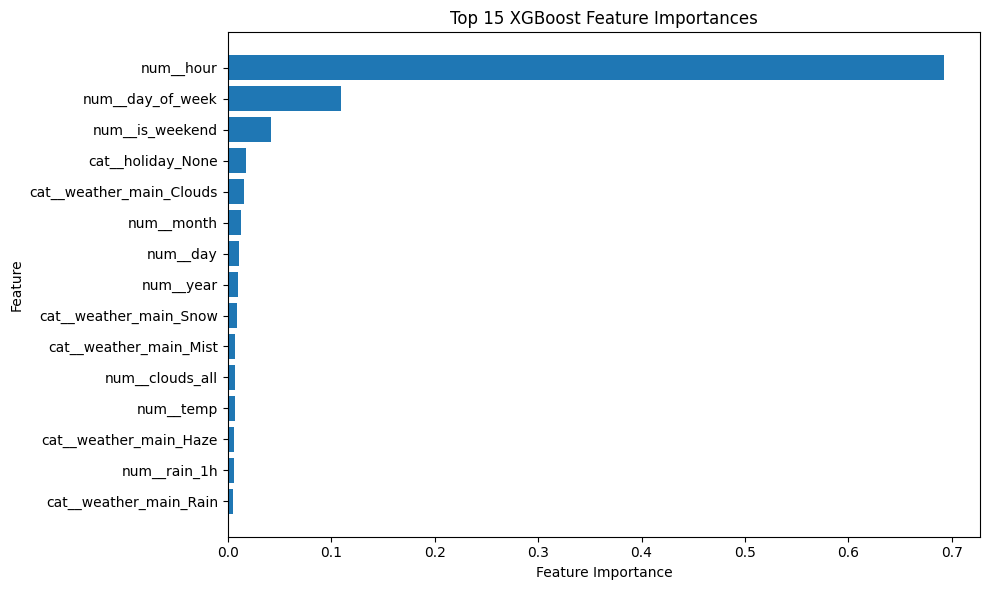

In [93]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")

plt.tight_layout()
plt.show()

In [94]:
xgb_model.save_model("traffic_xgboost_model.json")

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [95]:
import joblib

joblib.dump(
    preprocessor,
    "traffic_preprocessor.pkl"
)

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


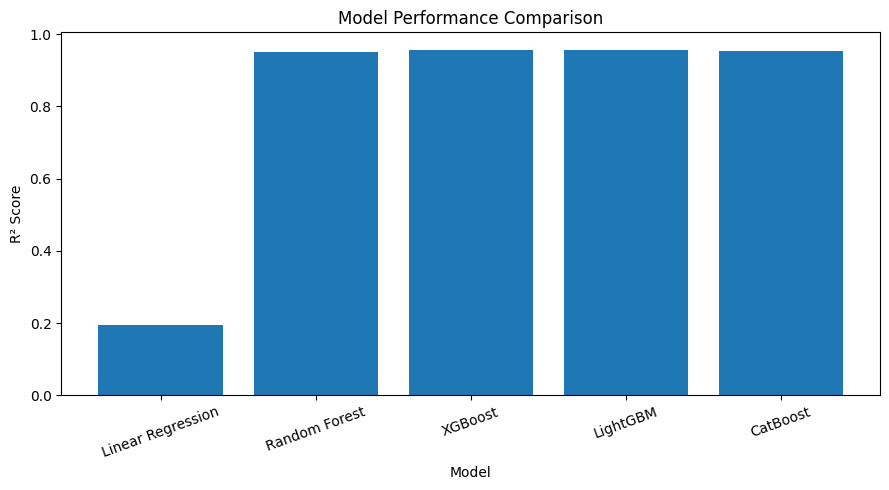

In [96]:
models = results_df["Model"]
r2_scores = results_df["R2"]

plt.figure(figsize=(9, 5))

plt.bar(models, r2_scores)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The Machine Learning models were evaluated for traffic-volume prediction using MAE, MSE, RMSE, and R² as performance metrics. The results show a significant difference between the linear and ensemble-based models.

Linear Regression performed relatively poorly, achieving an R² of only 0.1956 and an RMSE of 1766.93, indicating that the relationship between the input features and traffic volume is highly nonlinear.

The ensemble and boosting models performed substantially better. Random Forest achieved an R² of 0.9516, while LightGBM and CatBoost achieved R² values of 0.9560 and 0.9546, respectively. Among all the models, XGBoost performed the best, obtaining the lowest MAE (246.70) and RMSE (408.00), the lowest MSE (166,466.60), and the highest R² (0.9571).

Therefore, XGBoost was selected as the final Machine Learning model for the Smart Traffic Prediction system. Its performance indicates that approximately 95.7% of the variation in traffic volume in the test data is explained by the model.

Overall, the results demonstrate that tree-based ensemble and boosting techniques are much more suitable than simple linear regression for capturing the complex, nonlinear relationships between traffic volume, temporal features, and weather conditions. The selected XGBoost model can therefore serve as the primary ML component of the proposed Smart Traffic Prediction system.

In [97]:
import os

print("Saved files:")
for file in os.listdir():
    print(file)

Saved files:
.config
Temperature vs Traffic Volume.png
Metro_Interstate_Traffic_Volume.csv.gz
Average Traffic Volume by Weather Condition.png
catboost_info
Distribution of Traffic Volume.png
traffic_preprocessor.pkl
smart_traffic_ml_cleaned.csv
Correlation Heatmap of Numerical Features.png
traffic_xgboost_model.json
Average Traffic Volume by Month.png
Weekday vs Weekend Traffic Volume.png
Traffic Volume Over Time.png
Average Traffic Volume by Day of Week.png
Average Traffic Volume by Hour.png
sample_data


In [98]:
# from google.colab import files

# files.download("traffic_xgboost_model.json")

In [99]:
# files.download("traffic_preprocessor.pkl")